# Recyclage et territoire : à la recherche d'un profil écologique géographique ?

## Problématique

Les questions écologiques constituent une thématique importante notamment dans la gestion des territoires. Partant de ce constat, nous avons cherché un indicateur de comportement écologique que l'on pourrait croiser avec des données géographiques liés à la population francaise. Nous avons donc décidé de nous interesser à la valorisation des déchets ménagers et assimilés (DMA). 
Nous allons montrer que cette valorisation n'est pas la même au sein de la France métropolitaine. En effet, les performances de valorisation varient considérablement d'un département à l'autre. Quels facteurs territoriaux et socio-économiques expliquent ces disparités ?

Ce notebook explore deux hypothèses principales :
1. **Hypothèse territoriale** : les départements ruraux, bénéficiant d'une gestion différente des déchets (compostage, valorisation organique), présenteraient de meilleurs taux de valorisation.
2. **Hypothèse socio-économique** : les départements plus aisés investiraient davantage dans les infrastructures de tri et de recyclage.

## Données utilisées

| Source | Fichier | Description |
|--------|---------|-------------|
| ADEME / SINOE | `SINOE04_DestinationDmaParTypeTraitement.csv` | Tonnages de déchets par type de traitement et département |
| INSEE | `FET2021-19.xlsx` | Grille de densité communale (typologie urbain/rural) |
| INSEE | `niv2021.xlsx` | Niveau de vie médian annuel par département(légèrement revu, les 3 premiers lignes ont été supprimées |

> **Pour faire tourner ce notebook ** : les fichiers de données doivent être placés dans le même répertoire que ce notebook. Les sources sont disponibles sur [data.ademe.fr](https://data.ademe.fr) et [insee.fr](https://insee.fr).

## Plan
1. Chargement et nettoyage des données
2. Analyse descriptive
3. Visualisations : distributions, nuages de points, cartes
4. Modélisation : corrélations et régression multiple
5. Conclusion

> **Les Notebooks de cours (pandas, géopandas et API) ont été utilisés comme aide pour l'analyse **



## 0. Quelques package necessaires : 

Installer les packages :
```bash
pip install pandas openpyxl geopandas matplotlib seaborn scipy statsmodels requests
```

In [60]:
import requests
import os
from cartiflette import carti_download

# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

# ── Répertoire de travail ──────────────────────────────────────────────────────
if "projet_pythonDS" not in os.getcwd():
    os.chdir("projet_pythonDS")
print(f"Répertoire courant : {os.getcwd()}")

# ── Paramètres globaux ─────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

print("Imports OK")


Répertoire courant : /home/onyxia/work/projet_pythonDS
Imports OK


## 1. Chargement et nettoyage des données

### 1.1 Données SINOE (déchets) — via API ADEME à faire, pour le moment on passe par le fichier local CSV

In [ ]:
import os

def charger_sinoe_api(fallback_path: str = "SINOE04_DestinationDmaParTypeTraitement.csv") -> pd.DataFrame:
    """
    Charge les données SINOE depuis le fichier CSV local.

    Retourne un DataFrame à l'échelle départementale avec :
    - taux_valorisation_pct : % de déchets valorisés (matière + organique)
    """
    if not os.path.exists(fallback_path):
        raise FileNotFoundError(
            f"  Fichier local introuvable : '{fallback_path}'.\n"
            f"   Téléchargez-le sur : https://data.ademe.fr"
        )

    df = pd.read_csv(fallback_path, sep=",", encoding="utf-8")
    print(f"📂 Données chargées depuis {fallback_path} ({len(df)} lignes)")
    print(f"   Années disponibles : {sorted(df['ANNEE'].unique())}")
    print(f"   Types de traitement : {df['L_TYP_REG_SERVICE'].nunique()} modalités")

    df["TONNAGE_DMA"] = (
        df["TONNAGE_DMA"].astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )
    print(f"   Valeurs manquantes sur TONNAGE_DMA : {df['TONNAGE_DMA'].isna().sum()}")

    df["code_dept"] = df["C_DEPT"].astype(str).str.zfill(2)
    df["departement"] = df["N_DEPT"]

    annee_max = df["ANNEE"].max()
    df = df[df["ANNEE"] == annee_max].copy()
    print(f"   Année retenue : {annee_max} ({len(df)} lignes)")

    types_valorisation = ["Valorisation matière", "Valorisation organique"]
    df["est_valorisation"] = df["L_TYP_REG_SERVICE"].isin(types_valorisation)

    dept = (
        df.groupby(["code_dept", "departement"], as_index=False)
        .agg(
            tonnage_total=("TONNAGE_DMA", "sum"),
            tonnage_valorisation=(
                "TONNAGE_DMA",
                lambda x: x[df.loc[x.index, "est_valorisation"]].sum()
            ),
        )
    )
    dept["taux_valorisation_pct"] = (
        dept["tonnage_valorisation"] / dept["tonnage_total"] * 100
    )
    return dept


sinoe_dept = charger_sinoe_api("SINOE04_DestinationDmaParTypeTraitement.csv")
display(sinoe_dept.head())


📂 Données chargées depuis SINOE04_DestinationDmaParTypeTraitement.csv (14660 lignes)
   Années disponibles : [np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
   Types de traitement : 7 modalités
   Valeurs manquantes sur TONNAGE_DMA : 0
   Année retenue : 2021 (2004 lignes)


,code_dept,departement,tonnage_total,tonnage_valorisation,taux_valorisation_pct
0,01,Ain,383489.91,216910.20,56.562166
1,02,Aisne,328139.23,141321.50,43.067542
2,03,Allier,211885.62,91966.79,43.403979
3,04,Alpes-de-Haute-Provence,136286.08,55340.42,40.606069
4,05,Hautes-Alpes,98738.31,42461.21,43.003784


### 1.2 Données FET (ruralité)

In [62]:
def charger_ruralite(path: str) -> pd.DataFrame:
    """Charge et nettoie les données FET (grille de densité INSEE).
    
    Retourne un DataFrame à l'échelle départementale avec :
    - part_communes_rurales_pct : % de communes peu ou très peu denses
    
    Limite connue : l'indicateur n'est pas pondéré par la population,
    ce qui peut surreprésenter des communes faiblement peuplées.
    """
    df = pd.read_excel(path, sheet_name="Figure 1", skiprows=2)
    df.columns = ["code_commune", "lib_commune", "code_typologie", "lib_typologie"]

    print(f"Nombre de communes : {len(df)}")
    print(f"Typologies présentes : {df['lib_typologie'].unique()}")
    print(f"Valeurs manquantes : {df.isna().sum().to_dict()}")

    df["code_commune"] = df["code_commune"].astype(str).str.zfill(5)
    df["code_dept"] = df["code_commune"].str[:2]

    types_ruraux = ["Communes peu denses", "Communes très peu denses"]
    df["est_rural"] = df["lib_typologie"].isin(types_ruraux)

    dept = (
        df.groupby("code_dept", as_index=False)
        .agg(
            nb_communes=("code_commune", "count"),
            nb_communes_rurales=("est_rural", "sum"),
        )
    )
    dept["part_communes_rurales_pct"] = (
        dept["nb_communes_rurales"] / dept["nb_communes"] * 100
    )
    return dept


ruralite_dept = charger_ruralite("FET2021-19.xlsx")
display(ruralite_dept.head())

Nombre de communes : 34970
Typologies présentes : ['Communes peu denses' 'Communes très peu denses'
 'Communes de densité intermédiaire' 'Communes densément peuplées' nan]
Valeurs manquantes : {'code_commune': 0, 'lib_commune': 2, 'code_typologie': 2, 'lib_typologie': 2}


,code_dept,nb_communes,nb_communes_rurales,part_communes_rurales_pct
0,01,393,328,83.460560
1,02,800,757,94.625000
2,03,317,303,95.583596
3,04,198,187,94.444444
4,05,162,157,96.913580


### 1.3 Données INSEE (niveau de vie médian)

In [63]:
def charger_niveau_vie(path: str) -> pd.DataFrame:
    """Charge et nettoie les données INSEE sur le niveau de vie médian.
    
    Retourne un DataFrame à l'échelle départementale avec :
    - niveau_vie_median : niveau de vie annuel médian en euros
    """
    df = pd.read_excel(path, sheet_name="Territoire - Figure 1")
    print(f"Colonnes disponibles : {df.columns.tolist()}")
    print(f"Dimensions : {df.shape}")

    df = df.rename(columns={
        "Code département": "code_dept",
        "Département": "departement_rev",
        "Niveau de vie annuel médian": "niveau_vie_median",
    })
    df["code_dept"] = df["code_dept"].astype(str).str.zfill(2)
    df["niveau_vie_median"] = pd.to_numeric(df["niveau_vie_median"], errors="coerce")

    print(f"\nValeurs manquantes sur niveau_vie_median : {df['niveau_vie_median'].isna().sum()}")
    return df[["code_dept", "departement_rev", "niveau_vie_median"]]


revenu_dept = charger_niveau_vie("niv2021.xlsx")
display(revenu_dept.head())

Colonnes disponibles : ['Code département', 'Département', 'Niveau de vie annuel médian']
Dimensions : (105, 3)

Valeurs manquantes sur niveau_vie_median : 4


,code_dept,departement_rev,niveau_vie_median
0,01,Ain,24810.0
1,02,Aisne,20920.0
2,03,Allier,21500.0
3,04,Alpes-de-Haute-Provence,21790.0
4,05,Hautes-Alpes,22010.0


### Description et limites des sources de données

#### SINOE — Destination des DMA par type de traitement (ADEME)
- **Source** : ADEME / Système d'Information sur les Déchets et les Emballages (SINOE), [data.ademe.fr](https://data.ademe.fr)
- **Granularité** : département × type de traitement × année (années impaires de 2009 à 2021)
- **Variables construites** :
  - `taux_valorisation_pct` : % de déchets valorisés (matière + organique) sur le tonnage total
  - `kg_dma_par_habitant` : kilogrammes de déchets ménagers et assimilés produits par habitant *(nouvelle variable)*
- **⚠️ Limite — `taux_valorisation_pct`** : cet indicateur reflète les **choix d'infrastructure des collectivités** (filières de tri, équipements de compostage, contrats prestataires), et non le comportement individuel de tri. Un département affichant un fort taux peut l'être grâce à un investissement dans une unité de compostage industriel, indépendamment du geste de tri de ses habitants.
- **✅ Intérêt de `kg_dma_par_habitant`** : la quantité de déchets produits par habitant constitue un meilleur proxy du **comportement de sobriété** — moins on produit, plus on est sobre. Cette variable est moins dépendante des choix d'infrastructures.

#### FET2021-19 — Grille de densité communale (INSEE, 2021)
- **Source** : INSEE, [insee.fr](https://www.insee.fr/fr/statistiques/5039991)
- **Granularité** : commune (~35 000 communes), agrégée au département
- **Variable construite** : `part_communes_rurales_pct` = % de communes *peu denses* ou *très peu denses*
- **⚠️ Limite** : indicateur **non pondéré par la population**. Un département à nombreuses petites communes rurales peu peuplées obtient un score élevé, même si la majorité des habitants vivent en ville.

#### niv2021 — Niveau de vie médian départemental (INSEE, 2021)
- **Source** : INSEE, Fichier de revenus localisés des ménages (FiLoSoFi), [insee.fr](https://www.insee.fr/fr/statistiques/6692392)
- **Variable** : `niveau_vie_median` — niveau de vie annuel médian en euros
- **⚠️ Limite** : faible variance inter-départementale qui limite le pouvoir discriminant dans la régression.

#### Population légale 2021 (INSEE) — *source additionnelle pour la normalisation*
- **Source** : INSEE, Populations légales 2021, [insee.fr](https://www.insee.fr/fr/statistiques/6683035)
- **Usage** : normalisation du tonnage SINOE pour calculer `kg_dma_par_habitant`
- **Note reproductibilité** : intégrée directement dans le code (table de référence) pour éviter une dépendance à un fichier supplémentaire.


### 1.4 Indicateur comportemental : kg de DMA par habitant

Le taux de valorisation mesure l'efficacité des filières de traitement, mais pas directement le comportement des ménages. Nous construisons un second indicateur : le **nombre de kg de déchets ménagers et assimilés produits par habitant et par an**.

Un département où les habitants produisent peu de déchets témoigne :
- d'une pratique plus répandue du compostage individuel (déchets organiques non mis en poubelle),
- de comportements d'achat plus sobres (moins d'emballages),
- ou d'une structure démographique particulière (logements collectifs vs maisons individuelles).

> **Biais à noter** : cet indicateur est sensible au tourisme. Les départements très touristiques (Landes, Var...) ont une population réelle en saison bien supérieure à leur population légale, ce qui gonfle artificiellement leur kg/habitant calculé.


In [64]:
def charger_population() -> pd.DataFrame:
    """
    Population légale 2021 par département (INSEE).
    Source : https://www.insee.fr/fr/statistiques/6683035
    Intégrée directement pour garantir la reproductibilité sans fichier supplémentaire.
    """
    pop_2021 = {
        "01": 658_985, "02": 523_219, "03": 332_279, "04": 166_782, "05": 138_569,
        "06": 1_085_469, "07": 331_113, "08": 269_002, "09": 152_192, "10": 305_449,
        "11": 380_506, "12": 280_915, "13": 2_055_897, "14": 697_386, "15": 141_773,
        "16": 354_283, "17": 655_454, "18": 295_420, "19": 239_469, "21": 530_756,
        "22": 609_018, "23": 112_931, "24": 412_953, "25": 545_659, "26": 516_762,
        "27": 604_210, "28": 413_680, "29": 902_895, "2A": 161_636, "2B": 185_829,
        "30": 754_194, "31": 1_417_006, "32": 190_451, "33": 1_623_749, "34": 1_144_892,
        "35": 1_092_225, "36": 218_023, "37": 607_320, "38": 1_258_722, "39": 261_592,
        "40": 425_038, "41": 335_310, "42": 746_128, "43": 227_283, "44": 1_430_670,
        "45": 684_130, "46": 174_208, "47": 334_282, "48": 76_601, "49": 813_906,
        "50": 494_080, "51": 563_463, "52": 170_265, "53": 301_432, "54": 731_158,
        "55": 183_325, "56": 757_322, "57": 1_046_349, "58": 206_660, "59": 2_614_704,
        "60": 833_938, "61": 277_149, "62": 1_454_453, "63": 657_417, "64": 683_571,
        "65": 224_515, "66": 476_702, "67": 1_137_866, "68": 773_128, "69": 1_870_640,
        "70": 231_017, "71": 546_853, "72": 566_601, "73": 439_485, "74": 833_586,
        "75": 2_133_111, "76": 1_262_616, "77": 1_418_834, "78": 1_446_773, "79": 371_303,
        "80": 567_979, "81": 393_592, "82": 262_189, "83": 1_079_402, "84": 565_949,
        "85": 693_299, "86": 434_521, "87": 369_770, "88": 355_961, "89": 332_284,
        "90": 160_716, "91": 1_296_130, "92": 1_624_357, "93": 1_646_692, "94": 1_380_168,
        "95": 1_240_620,
    }
    return pd.DataFrame([
        {"code_dept": k, "population_2021": v}
        for k, v in pop_2021.items()
    ])

pop_dept = charger_population()
print(f"Départements chargés : {len(pop_dept)}")
display(pop_dept.head())


Départements chargés : 96


,code_dept,population_2021
0,01,658985
1,02,523219
2,03,332279
3,04,166782
4,05,138569


In [65]:
def calculer_kg_par_habitant(path_sinoe: str, pop_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule le tonnage de DMA par habitant à l'échelle départementale.

    Retourne un DataFrame avec :
    - kg_dma_par_habitant : proxy de sobriété (moins = mieux)
    - population_2021 : population légale pour référence
    """
    df_s = pd.read_csv(path_sinoe, sep=",", encoding="utf-8")
    df_s["TONNAGE_DMA"] = (
        df_s["TONNAGE_DMA"].astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )
    df_s["code_dept"] = df_s["C_DEPT"].astype(str).str.zfill(2)
    annee_max = df_s["ANNEE"].max()
    df_s = df_s[df_s["ANNEE"] == annee_max]

    tonnage_dept = (
        df_s.groupby("code_dept", as_index=False)
        .agg(tonnage_total=("TONNAGE_DMA", "sum"))
    )
    merged = tonnage_dept.merge(pop_df, on="code_dept", how="inner")
    merged["kg_dma_par_habitant"] = (
        merged["tonnage_total"] * 1000 / merged["population_2021"]
    )
    print(f"Moyenne nationale : {merged['kg_dma_par_habitant'].mean():.0f} kg/hab/an")
    print(f"Écart-type        : {merged['kg_dma_par_habitant'].std():.0f} kg/hab/an")
    return merged[["code_dept", "kg_dma_par_habitant", "population_2021"]]

kg_dept = calculer_kg_par_habitant("SINOE04_DestinationDmaParTypeTraitement.csv", pop_dept)
display(kg_dept.head())


Moyenne nationale : 638 kg/hab/an
Écart-type        : 105 kg/hab/an


,code_dept,kg_dma_par_habitant,population_2021
0,01,581.940272,658985
1,02,627.154652,523219
2,03,637.673822,332279
3,04,817.151012,166782
4,05,712.556993,138569


In [66]:
# ── Jointure enrichie avec kg/habitant ──

def joindre_ruralite(df_base, df_rural):
    """Joint les données de ruralité sur code_dept."""
    return df_base.merge(df_rural, on="code_dept", how="inner")

def joindre_revenu(df_base, df_rev):
    """Joint le niveau de vie médian sur code_dept."""
    return df_base.merge(df_rev[["code_dept", "niveau_vie_median"]], on="code_dept", how="left")

def joindre_population(df_base, df_pop):
    """Joint kg/habitant et population sur code_dept."""
    return df_base.merge(
        df_pop[["code_dept", "kg_dma_par_habitant", "population_2021"]],
        on="code_dept", how="left"
    )

def ajouter_variables_centrees(df_base):
    """Crée les variables centrées et le terme d'interaction pour la régression."""
    df_base = df_base.copy()
    df_base["rural_c"] = df_base["part_communes_rurales_pct"] - df_base["part_communes_rurales_pct"].mean()
    df_base["revenu_c"] = df_base["niveau_vie_median"] - df_base["niveau_vie_median"].mean()
    df_base["interaction_rural_revenu"] = df_base["rural_c"] * df_base["revenu_c"]
    return df_base

# Chaîne de traitement lisible avec .pipe() — évite les affectations intermédiaires
df = (
    sinoe_dept
    .pipe(joindre_ruralite, ruralite_dept)
    .pipe(joindre_revenu, revenu_dept)
    .pipe(joindre_population, kg_dept)
    .pipe(ajouter_variables_centrees)
)

print(f"Départements dans la table finale : {len(df)}")
print("Valeurs manquantes :")
print(df[["taux_valorisation_pct", "part_communes_rurales_pct",
           "niveau_vie_median", "kg_dma_par_habitant"]].isna().sum())
display(df.head())


Départements dans la table finale : 96
Valeurs manquantes :
taux_valorisation_pct        0
part_communes_rurales_pct    0
niveau_vie_median            0
kg_dma_par_habitant          0
dtype: int64


,code_dept,departement,tonnage_total,tonnage_valorisation,taux_valorisation_pct,nb_communes,nb_communes_rurales,part_communes_rurales_pct,niveau_vie_median,kg_dma_par_habitant,population_2021,rural_c,revenu_c,interaction_rural_revenu
0,01,Ain,383489.91,216910.20,56.562166,393,328,83.460560,24810.0,581.940272,658985,-0.513909,2103.333333,-1080.922052
1,02,Aisne,328139.23,141321.50,43.067542,800,757,94.625000,20920.0,627.154652,523219,10.650531,-1786.666667,-19028.948980
2,03,Allier,211885.62,91966.79,43.403979,317,303,95.583596,21500.0,637.673822,332279,11.609127,-1206.666667,-14008.347014
3,04,Alpes-de-Haute-Provence,136286.08,55340.42,40.606069,198,187,94.444444,21790.0,817.151012,166782,10.469976,-916.666667,-9597.477624
4,05,Hautes-Alpes,98738.31,42461.21,43.003784,162,157,96.913580,22010.0,712.556993,138569,12.939111,-696.666667,-9014.247603


In [67]:
print("Départements absents de SINOE :")
print(sorted(set(kg_dept["code_dept"]) - set(sinoe_dept["code_dept"])))

Départements absents de SINOE :
[]


## 2. Analyse descriptive

Avant toute modélisation, cette section présente une analyse descriptive des quatre variables principales : le taux de valorisation, la production de déchets par habitant, la part de communes rurales et le niveau de vie médian.


In [68]:
stats = df[[
    "taux_valorisation_pct",
    "kg_dma_par_habitant",
    "part_communes_rurales_pct",
    "niveau_vie_median"
]].describe().round(2)
stats.index.name = "Statistique"
display(stats)


,taux_valorisation_pct,kg_dma_par_habitant,part_communes_rurales_pct,niveau_vie_median
Statistique,,,,
count,96.00,96.00,96.00,96.00
mean,49.42,637.99,83.97,22706.67
std,9.78,104.98,21.79,1721.89
min,29.33,398.96,0.00,19020.00
25%,43.34,575.36,82.23,21575.00
50%,47.89,628.82,92.84,22285.00
75%,53.70,697.56,95.94,23292.50
max,87.60,1101.01,99.61,29730.00


**Lecture du tableau :**
Le taux de valorisation moyen est d'environ **49 %** avec une dispersion 
importante (écart-type ~10 pts, min 29 % – max 88 %), signe de fortes 
inégalités inter-départementales.
La quantité moyenne de DMA par habitant et par an  est d'environ **638 kg** avec une dispersion (écart-type ~105 kg, min 399 kg – max 1100 kg), signe de grandes 
inégalités inter-départementales.
La part de communes rurales est très élevée en moyenne (84 %), mais la 
distribution est très asymétrique : la médiane est à 93 %, ce qui reflète 
une France majoritairement rurale en nombre de communes, avec quelques 
grands départements urbains qui tirent la moyenne vers le bas (min = 0 pour 
Paris).
Le niveau de vie médian (attention valeur annuelle) est le plus concentré des trois (std = 1722 €) 
et les départements sont relativement homogènes sur ce plan.

In [69]:
print("Top 10 — taux de valorisation le plus élevé")
display(
    df[["code_dept", "departement", "taux_valorisation_pct", "part_communes_rurales_pct"]]
    .sort_values("taux_valorisation_pct", ascending=False)
    .head(10)
    .round(2)
    .reset_index(drop=True)
)

print("\nFlop 10 — taux de valorisation le plus bas")
display(
    df[["code_dept", "departement", "taux_valorisation_pct", "part_communes_rurales_pct"]]
    .sort_values("taux_valorisation_pct", ascending=True)
    .head(10)
    .round(2)
    .reset_index(drop=True)
)

Top 10 — taux de valorisation le plus élevé


,code_dept,departement,taux_valorisation_pct,part_communes_rurales_pct
0,85,Vendée,87.60,93.41
1,71,Saône-et-Loire,73.28,93.98
2,64,Pyrénées-Atlantiques,72.06,89.01
3,16,Charente,71.25,95.63
4,79,Deux-Sèvres,70.23,94.92
5,17,Charente-Maritime,65.86,91.79
6,34,Hérault,65.50,77.49
7,40,Landes,65.33,94.19
8,43,Haute-Loire,62.48,94.16
9,22,Cotes-d'Armor,60.03,92.82



Flop 10 — taux de valorisation le plus bas


,code_dept,departement,taux_valorisation_pct,part_communes_rurales_pct
0,75,Paris,29.33,0.00
1,93,Seine-Saint-Denis,30.25,0.00
2,94,Val-de-Marne,31.00,0.00
3,2A,Corse-du-Sud,31.11,98.39
4,92,Hauts-de-seine,32.82,0.00
5,52,Haute-Marne,35.13,98.59
6,77,Seine-et-Marne,36.03,71.99
7,95,Val-d'Oise,36.20,47.83
8,66,Pyrénées-Orientales,38.65,81.42
9,13,Bouches-du-Rhône,39.55,38.66


**Observation :** les départements en tête de classement sont majoritairement ruraux, ce qui va dans le sens de l'hypothèse territoriale. Les derniers du classement sont souvent des départements à forte concentration urbaine. Ce constat visuel sera confirmé (ou infirmé) par l'analyse statistique.

## 3. Visualisations

### 3.1 Distributions des variables

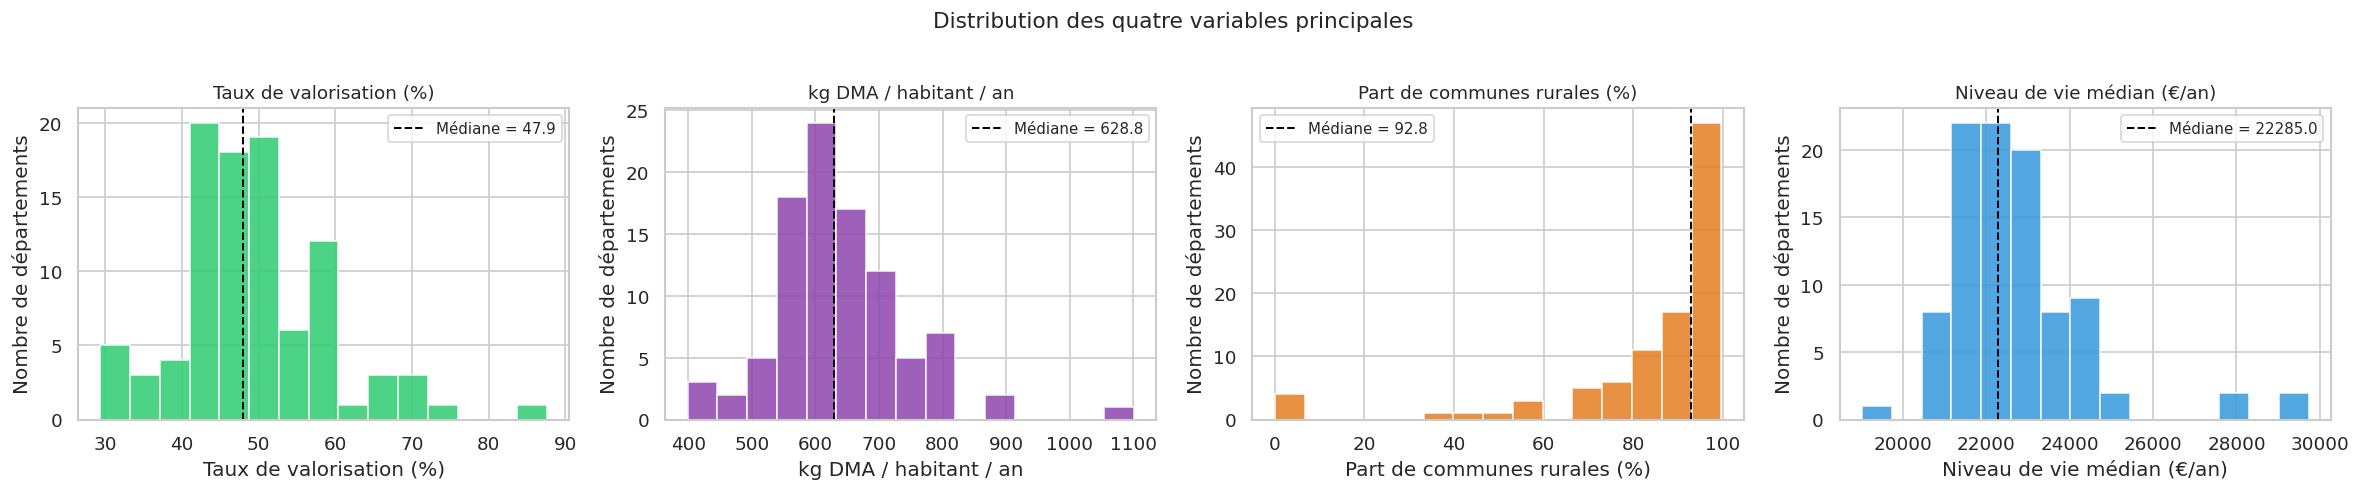

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

vars_labels = [
    ("taux_valorisation_pct",     "Taux de valorisation (%)",      "#2ecc71"),
    ("kg_dma_par_habitant",       "kg DMA / habitant / an",        "#8e44ad"),
    ("part_communes_rurales_pct", "Part de communes rurales (%)",  "#e67e22"),
    ("niveau_vie_median",         "Niveau de vie médian (€/an)",   "#3498db"),
]

for ax, (col, label, color) in zip(axes, vars_labels):
    ax.hist(df[col].dropna(), bins=15, color=color, edgecolor="white", alpha=0.85)
    med = df[col].median()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.2, label=f"Médiane = {med:.1f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel("Nombre de départements")
    ax.legend(fontsize=9)

plt.suptitle("Distribution des quatre variables principales", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Lecture :** La distribution du taux de valorisation est relativement symétrique autour de la médiane. Même chose pour la distribution dela quantité de DMA par habitant et par an. La ruralité présente une distribution bimodale (départements très ruraux vs. très urbains), ce qui pourra générer une relation non-linéaire avec la valorisation. Le niveau de vie médian est quant à lui concentré autour d'une plage relativement étroite, avec quelques départements à fort revenu.

### 3.2 Nuages de points : ruralité, niveau de vie et valorisation

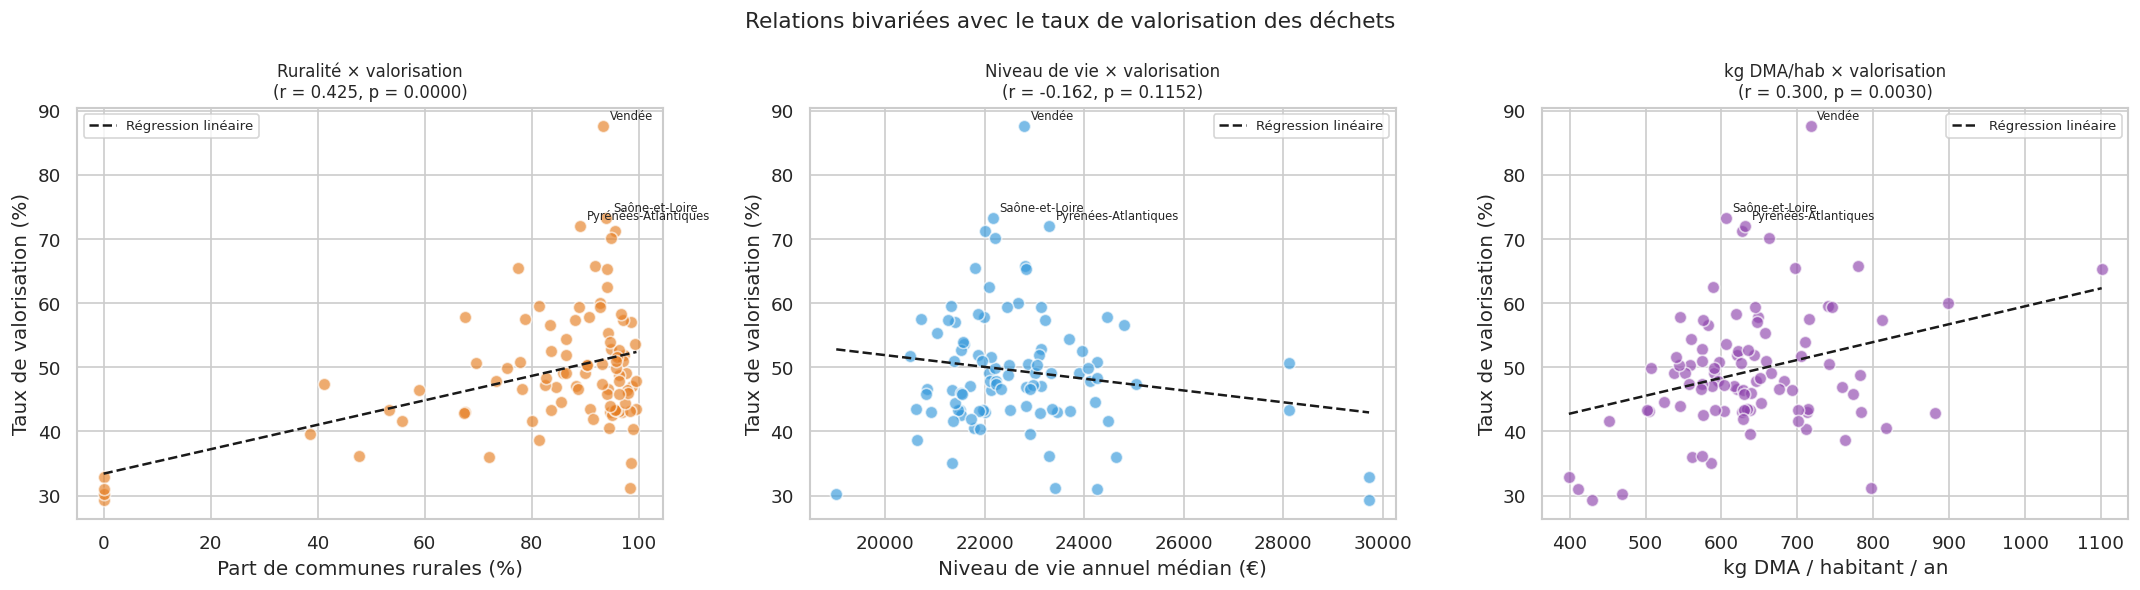

In [71]:
import numpy as np

def scatter_avec_regression(ax, x_col, y_col, xlabel, ylabel, title, color):
    """Nuage de points avec droite de régression et annotation des outliers."""
    tmp = df[[x_col, y_col, "departement"]].dropna()

    ax.scatter(tmp[x_col], tmp[y_col], alpha=0.6, color=color, edgecolors="white", s=50)

    # Droite de régression (numpy.polyfit, pd.np supprimé depuis pandas 1.0)
    m, b = np.polyfit(tmp[x_col], tmp[y_col], 1)
    x_range = np.linspace(tmp[x_col].min(), tmp[x_col].max(), 100)
    ax.plot(x_range, m * x_range + b, color="black", linewidth=1.5, linestyle="--", label="Régression")

    # Annotation des 3 outliers les plus éloignés de la droite
    residus = tmp[y_col] - (m * tmp[x_col] + b)
    outliers = residus.abs().nlargest(3).index
    for idx in outliers:
        ax.annotate(
            tmp.loc[idx, "departement"],
            (tmp.loc[idx, x_col], tmp.loc[idx, y_col]),
            fontsize=7, xytext=(4, 4), textcoords="offset points"
        )

    r, p = pearsonr(tmp[x_col], tmp[y_col])
    ax.set_title(f"{title}\n(r = {r:.3f}, p = {p:.3f})", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter 1 : ruralité vs valorisation
tmp1 = df[["part_communes_rurales_pct", "taux_valorisation_pct", "departement"]].dropna()
axes[0].scatter(tmp1["part_communes_rurales_pct"], tmp1["taux_valorisation_pct"],
               alpha=0.65, color="#e67e22", edgecolors="white", s=55)
m1, b1 = np.polyfit(tmp1["part_communes_rurales_pct"], tmp1["taux_valorisation_pct"], 1)
x1 = np.linspace(tmp1["part_communes_rurales_pct"].min(), tmp1["part_communes_rurales_pct"].max(), 100)
axes[0].plot(x1, m1*x1+b1, "k--", linewidth=1.5, label="Régression linéaire")
res1 = tmp1["taux_valorisation_pct"] - (m1*tmp1["part_communes_rurales_pct"]+b1)
for idx in res1.abs().nlargest(3).index:
    axes[0].annotate(tmp1.loc[idx, "departement"],
                    (tmp1.loc[idx, "part_communes_rurales_pct"], tmp1.loc[idx, "taux_valorisation_pct"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
r1, p1 = pearsonr(tmp1["part_communes_rurales_pct"], tmp1["taux_valorisation_pct"])
axes[0].set_title(f"Ruralité × valorisation\n(r = {r1:.3f}, p = {p1:.4f})", fontsize=10)
axes[0].set_xlabel("Part de communes rurales (%)")
axes[0].set_ylabel("Taux de valorisation (%)")
axes[0].legend(fontsize=8)

# Scatter 2 : niveau de vie vs valorisation
tmp2 = df[["niveau_vie_median", "taux_valorisation_pct", "departement"]].dropna()
axes[1].scatter(tmp2["niveau_vie_median"], tmp2["taux_valorisation_pct"],
               alpha=0.65, color="#3498db", edgecolors="white", s=55)
m2, b2 = np.polyfit(tmp2["niveau_vie_median"], tmp2["taux_valorisation_pct"], 1)
x2 = np.linspace(tmp2["niveau_vie_median"].min(), tmp2["niveau_vie_median"].max(), 100)
axes[1].plot(x2, m2*x2+b2, "k--", linewidth=1.5, label="Régression linéaire")
res2 = tmp2["taux_valorisation_pct"] - (m2*tmp2["niveau_vie_median"]+b2)
for idx in res2.abs().nlargest(3).index:
    axes[1].annotate(tmp2.loc[idx, "departement"],
                    (tmp2.loc[idx, "niveau_vie_median"], tmp2.loc[idx, "taux_valorisation_pct"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
r2, p2 = pearsonr(tmp2["niveau_vie_median"], tmp2["taux_valorisation_pct"])
axes[1].set_title(f"Niveau de vie × valorisation\n(r = {r2:.3f}, p = {p2:.4f})", fontsize=10)
axes[1].set_xlabel("Niveau de vie annuel médian (€)")
axes[1].set_ylabel("Taux de valorisation (%)")
axes[1].legend(fontsize=8)

# Scatter 3 : kg/habitant vs valorisation
tmp3 = df[["kg_dma_par_habitant", "taux_valorisation_pct", "departement"]].dropna()
axes[2].scatter(tmp3["kg_dma_par_habitant"], tmp3["taux_valorisation_pct"],
               alpha=0.65, color="#8e44ad", edgecolors="white", s=55)
m3, b3 = np.polyfit(tmp3["kg_dma_par_habitant"], tmp3["taux_valorisation_pct"], 1)
x3 = np.linspace(tmp3["kg_dma_par_habitant"].min(), tmp3["kg_dma_par_habitant"].max(), 100)
axes[2].plot(x3, m3*x3+b3, "k--", linewidth=1.5, label="Régression linéaire")
res3 = tmp3["taux_valorisation_pct"] - (m3*tmp3["kg_dma_par_habitant"]+b3)
for idx in res3.abs().nlargest(3).index:
    axes[2].annotate(tmp3.loc[idx, "departement"],
                    (tmp3.loc[idx, "kg_dma_par_habitant"], tmp3.loc[idx, "taux_valorisation_pct"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
r3, p3 = pearsonr(tmp3["kg_dma_par_habitant"], tmp3["taux_valorisation_pct"])
axes[2].set_title(f"kg DMA/hab × valorisation\n(r = {r3:.3f}, p = {p3:.4f})", fontsize=10)
axes[2].set_xlabel("kg DMA / habitant / an")
axes[2].set_ylabel("Taux de valorisation (%)")
axes[2].legend(fontsize=8)

plt.suptitle("Relations bivariées avec le taux de valorisation des déchets", fontsize=13)
plt.tight_layout()
plt.show()


**Lecture :**
- **Ruralité (gauche)** : relation positive significative — les départements ruraux valorisent mieux leurs déchets.
- **Niveau de vie (centre)** : pente quasi nulle, pas de relation linéaire claire entre revenu et valorisation, ce qui n'est pas très étonnant, le niveau de vie étant peu représentatif des disparités en France métropolitaine.
- **kg/habitant (droite)** : relation à interpréter avec soin — un département rural produit plus de déchets organiques (jardins) mais les valorise aussi mieux. Les deux phénomènes peuvent aller de pair, il faudrait considérer le taux de maisons individuelles (autre base de données à rechercher) pour valider cette hypothèse.
- Les départements annotés sont ceux dont les résidus sont les plus importants par rapport à la tendance générale.

### 3.3 Heatmap de corrélation

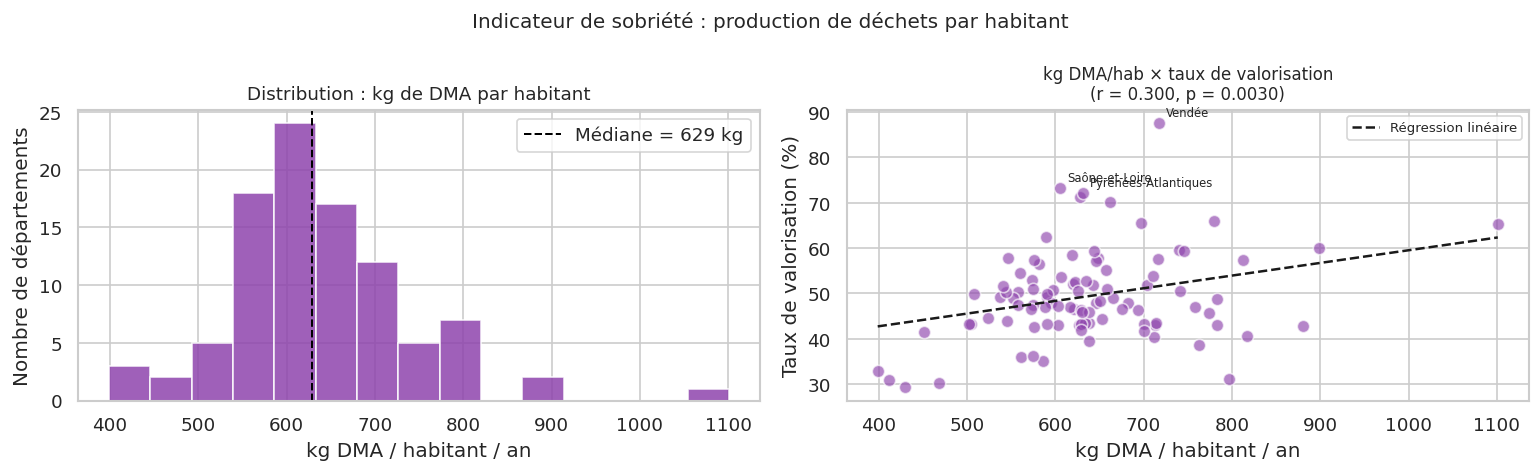

Top 5 — départements les plus sobres (kg/hab les plus bas) :


,code_dept,departement,kg_dma_par_habitant,part_communes_rurales_pct
0,92,Hauts-de-seine,399.0,0.0
1,94,Val-de-Marne,411.5,0.0
2,75,Paris,430.0,0.0
3,69,Rhône,451.5,55.8
4,93,Seine-Saint-Denis,468.4,0.0



Flop 5 — production la plus élevée :


,code_dept,departement,kg_dma_par_habitant,part_communes_rurales_pct
0,40,Landes,1101.0,94.2
1,22,Cotes-d'Armor,898.1,92.8
2,83,Var,880.9,67.3
3,04,Alpes-de-Haute-Provence,817.2,94.4
4,29,Finistère,812.0,88.1


In [72]:
# ── Distribution de kg_dma_par_habitant + scatter vs valorisation ───────────
import numpy as np
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme
axes[0].hist(df["kg_dma_par_habitant"].dropna(), bins=15,
             color="#8e44ad", edgecolor="white", alpha=0.85)
med_kg = df["kg_dma_par_habitant"].median()
axes[0].axvline(med_kg, color="black", linestyle="--", linewidth=1.2,
                label=f"Médiane = {med_kg:.0f} kg")
axes[0].set_title("Distribution : kg de DMA par habitant", fontsize=11)
axes[0].set_xlabel("kg DMA / habitant / an")
axes[0].set_ylabel("Nombre de départements")
axes[0].legend()

# Scatter kg/hab vs taux valorisation
tmp = df[["kg_dma_par_habitant", "taux_valorisation_pct", "departement"]].dropna()
axes[1].scatter(tmp["kg_dma_par_habitant"], tmp["taux_valorisation_pct"],
                alpha=0.65, color="#8e44ad", edgecolors="white", s=55)
m, b = np.polyfit(tmp["kg_dma_par_habitant"], tmp["taux_valorisation_pct"], 1)
x_range = np.linspace(tmp["kg_dma_par_habitant"].min(), tmp["kg_dma_par_habitant"].max(), 100)
axes[1].plot(x_range, m * x_range + b, "k--", linewidth=1.5, label="Régression linéaire")
r, p = pearsonr(tmp["kg_dma_par_habitant"], tmp["taux_valorisation_pct"])
residus = tmp["taux_valorisation_pct"] - (m * tmp["kg_dma_par_habitant"] + b)
for idx in residus.abs().nlargest(3).index:
    axes[1].annotate(tmp.loc[idx, "departement"],
                     (tmp.loc[idx, "kg_dma_par_habitant"], tmp.loc[idx, "taux_valorisation_pct"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set_title(f"kg DMA/hab × taux de valorisation\n(r = {r:.3f}, p = {p:.4f})", fontsize=10)
axes[1].set_xlabel("kg DMA / habitant / an")
axes[1].set_ylabel("Taux de valorisation (%)")
axes[1].legend(fontsize=8)

plt.suptitle("Indicateur de sobriété : production de déchets par habitant", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 — départements les plus sobres (kg/hab les plus bas) :")
display(df.nsmallest(5, "kg_dma_par_habitant")[
    ["code_dept", "departement", "kg_dma_par_habitant", "part_communes_rurales_pct"]
].round(1).reset_index(drop=True))
print("\nFlop 5 — production la plus élevée :")
display(df.nlargest(5, "kg_dma_par_habitant")[
    ["code_dept", "departement", "kg_dma_par_habitant", "part_communes_rurales_pct"]
].round(1).reset_index(drop=True))


**Lecture :**
La distribution de `kg_dma_par_habitant` est asymétrique à droite (moyenne ~638 kg, std ~105 kg). Les valeurs extrêmes hautes correspondent principalement à des **départements très touristiques** (Landes, Var, Finistère) dont la population en saison est bien supérieure à la population légale : ce biais gonfle artificiellement leur ratio et doit être mentionné lors de l'interprétation.

À l'inverse, les départements les plus sobres sont des zones urbaines denses (Hauts-de-Seine, Paris, Val-de-Marne) où les comportements de consommation et la structure des ménages (logements collectifs, moindre place pour les jardins et le compostage) limitent la production de déchets par habitant.


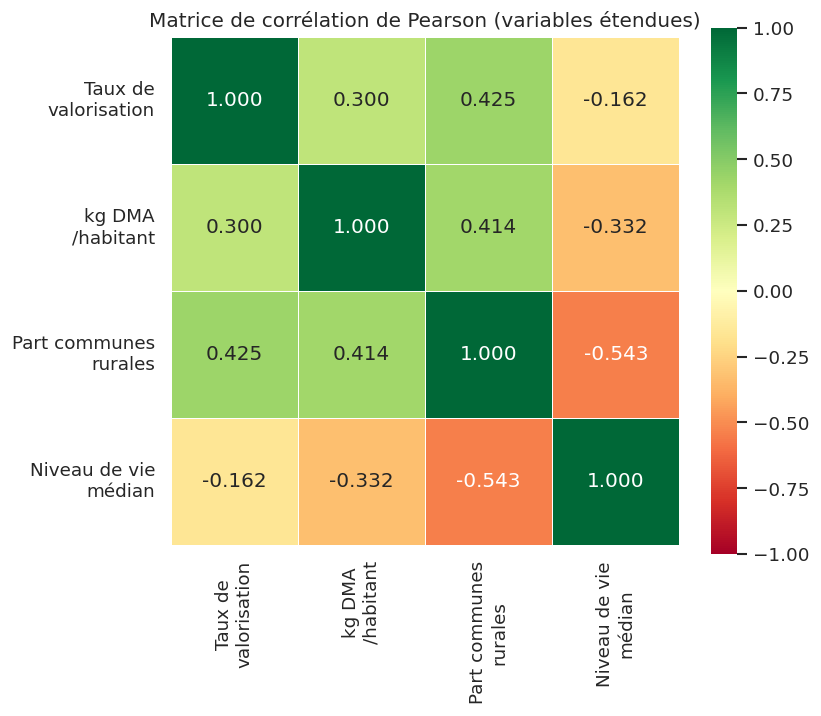

In [73]:
# ── Matrice de corrélation  (4 variables) ────────────────────────────
vars_corr2 = ["taux_valorisation_pct", "kg_dma_par_habitant",
              "part_communes_rurales_pct", "niveau_vie_median"]
labels_corr2 = ["Taux de\nvalorisation", "kg DMA\n/habitant",
                "Part communes\nrurales", "Niveau de vie\nmédian"]

mat_corr2 = df[vars_corr2].corr().round(3)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mat_corr2, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=-1, vmax=1,
    xticklabels=labels_corr2, yticklabels=labels_corr2,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Matrice de corrélation de Pearson (variables étendues)", fontsize=12)
plt.tight_layout()
plt.show()


**Lecture :** L'ajout de `kg_dma_par_habitant` dans la matrice permet de distinguer deux dimensions du comportement territorial :
- Le **taux de valorisation** capte l'efficacité du système de traitement (en aval).
- Le **kg/habitant** capte la sobriété dans la production (en amont).



### 3.4 Analyse cartographique

Les cartes permettent de donner une dimension géographique à l'analyse statistique. On utilise ici `geopandas` et `cartiflette` pour charger le fond de carte officiel IGN, conformément aux techniques vues dans le notebook `03_geopandas_intro` du cours (chargement via `carti_download`, jointure spatiale, carte choroplèthe avec `.plot(column=...)`).


In [74]:
GEOJSON_URL = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"

def charger_carte(df_data: pd.DataFrame) -> gpd.GeoDataFrame:
    """Charge le fond de carte et y joint les données départementales."""
    carte = gpd.read_file(GEOJSON_URL)
    carte["code"] = carte["code"].astype(str).str.zfill(2)
    df_data = df_data.copy()
    df_data["code_dept"] = df_data["code_dept"].astype(str).str.zfill(2)
    return carte.merge(df_data, left_on="code", right_on="code_dept", how="left")


carte = charger_carte(df)
print("Carte chargée :", len(carte), "départements")


Carte chargée : 96 départements


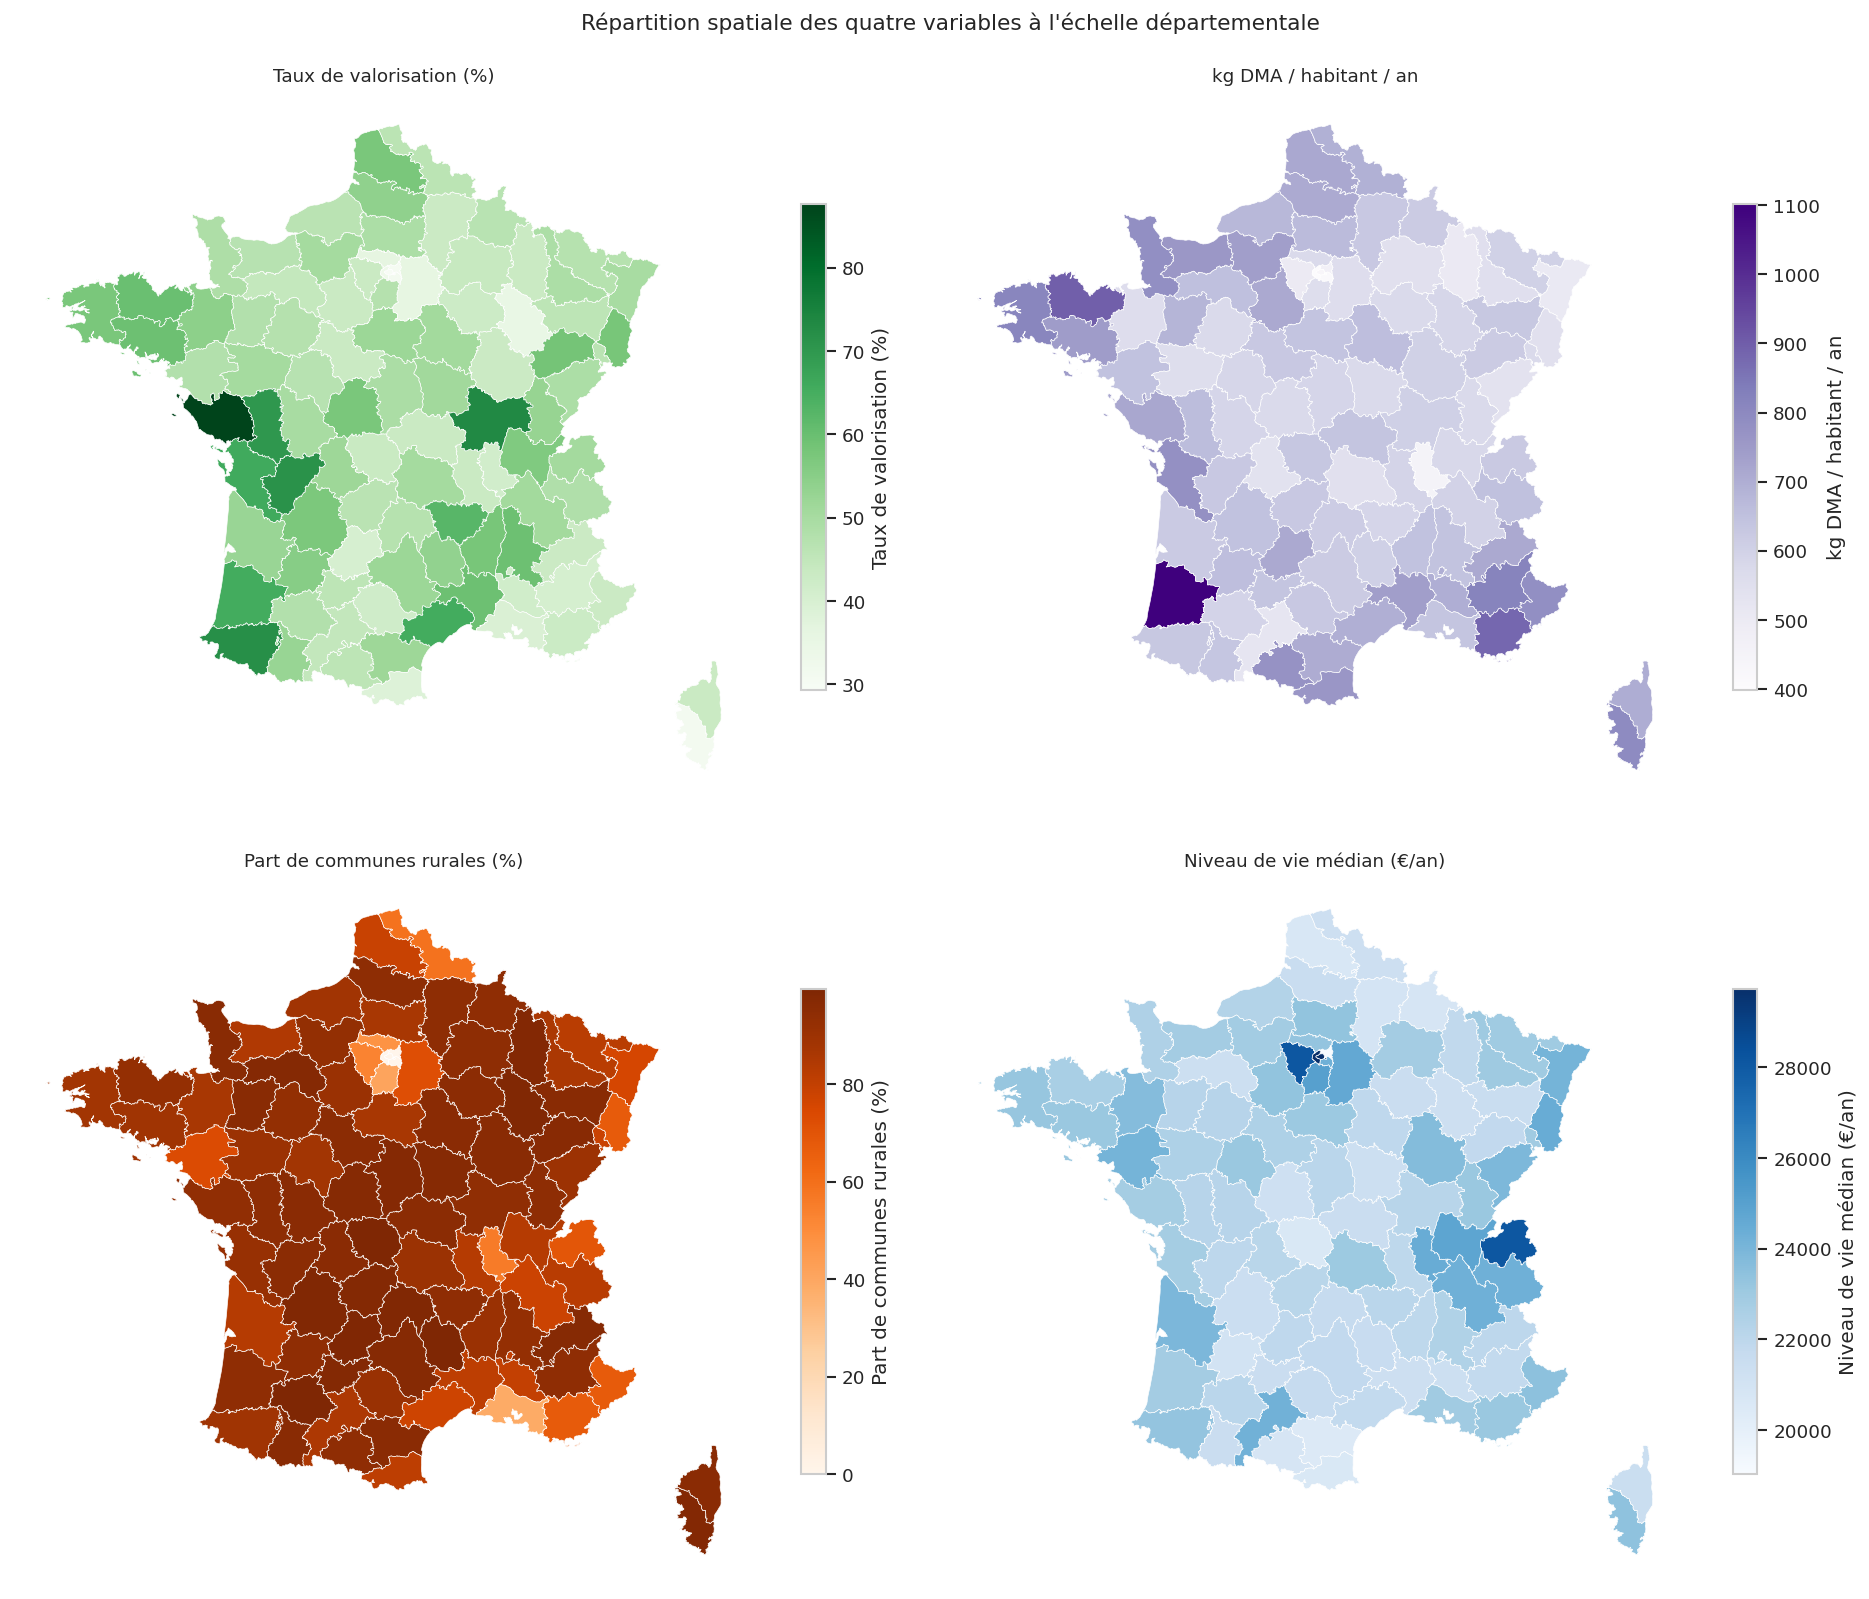

In [75]:
configs = [
    ("taux_valorisation_pct",     "Greens",  "Taux de valorisation (%)"),
    ("kg_dma_par_habitant",       "Purples", "kg DMA / habitant / an"),
    ("part_communes_rurales_pct", "Oranges", "Part de communes rurales (%)"),
    ("niveau_vie_median",          "Blues",   "Niveau de vie médian (€/an)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (col, cmap, title) in zip(axes, configs):
    carte.plot(
        column=col,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.6, "label": title},
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Donnée manquante"}
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Répartition spatiale des quatre variables à l'échelle départementale", fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des cartes :**
- La carte de valorisation (verte) révèle une **concentration des bons performeurs dans les zones rurales** 
(diagonale nord-est / sud-ouest et Massif Central), alors que les grandes métropoles affichent des taux plus faibles.
- La carte de kg/habitant (violette) montre une production plus élevée dans les **départements touristiques** 
(Landes, Var, Finistère) dont la population estivale gonfle artificiellement le ratio, et plus faible 
dans les départements urbains denses (Paris, Hauts-de-Seine).
- La carte de ruralité (orange) présente une structure spatiale similaire à celle de la valorisation, 
ce qui renforce visuellement la corrélation positive entre les deux variables.
- La carte de niveau de vie (bleue) présente un gradient différent, concentré autour de l'Île-de-France 
et de quelques métropoles — sa géographie est **distincte** de celle de la valorisation, cohérent avec 
l'absence de corrélation significative observée statistiquement.

In [76]:
# ── Carte typologique : 4 profils territoriaux ────────────────────────────────
med_valo  = df["taux_valorisation_pct"].median()
med_rural = df["part_communes_rurales_pct"].median()
med_kg    = df["kg_dma_par_habitant"].median()

print(f"Médianes — valorisation : {med_valo:.1f}% | ruralité : {med_rural:.1f}% | kg/hab : {med_kg:.0f} kg")

def profil_territorial(row):
    valo  = row["taux_valorisation_pct"] >= med_valo
    rural = row["part_communes_rurales_pct"] >= med_rural
    if   not rural and not valo: return "Urbain / valorisation faible"
    elif not rural and valo:     return "Urbain / valorisation forte"
    elif rural and not valo:     return "Rural / valorisation faible"
    else:                        return "Rural / valorisation forte"

def profil_sobriete(row):
    sobre = row["kg_dma_par_habitant"] <= med_kg  # moins = plus sobre
    rural = row["part_communes_rurales_pct"] >= med_rural
    if   not rural and not sobre: return "Urbain / peu sobre"
    elif not rural and sobre:     return "Urbain / sobre"
    elif rural and not sobre:     return "Rural / peu sobre"
    else:                         return "Rural / sobre"

ordre = [
    "Urbain / valorisation faible",
    "Urbain / valorisation forte",
    "Rural / valorisation faible",
    "Rural / valorisation forte",
]
ordre_sobriete = [
    "Urbain / peu sobre",
    "Urbain / sobre",
    "Rural / peu sobre",
    "Rural / sobre",
]
couleurs = {
    "Urbain / valorisation faible": "#f4a3a3",
    "Urbain / valorisation forte":  "#a8ddb5",
    "Rural / valorisation faible":  "#b30000",
    "Rural / valorisation forte":   "#006d2c",
}
couleurs_sobriete = {
    "Urbain / peu sobre": "#f4a3a3",
    "Urbain / sobre":     "#a8ddb5",
    "Rural / peu sobre":  "#b30000",
    "Rural / sobre":      "#006d2c",
}

df["profil"] = pd.Categorical(
    df.apply(profil_territorial, axis=1), categories=ordre, ordered=True
)
df["profil_sobriete"] = pd.Categorical(
    df.apply(profil_sobriete, axis=1), categories=ordre_sobriete, ordered=True
)

print("\nRépartition profil valorisation :")
display(df["profil"].value_counts().rename("Nombre de départements").to_frame())
print("\nRépartition profil sobriété :")
display(df["profil_sobriete"].value_counts().rename("Nombre de départements").to_frame())


Médianes — valorisation : 47.9% | ruralité : 92.8% | kg/hab : 629 kg

Répartition profil valorisation :


,Nombre de départements
profil,
Urbain / valorisation faible,25
Rural / valorisation forte,25
Urbain / valorisation forte,23
Rural / valorisation faible,23



Répartition profil sobriété :


,Nombre de départements
profil_sobriete,
Urbain / sobre,26
Rural / peu sobre,26
Urbain / peu sobre,22
Rural / sobre,22


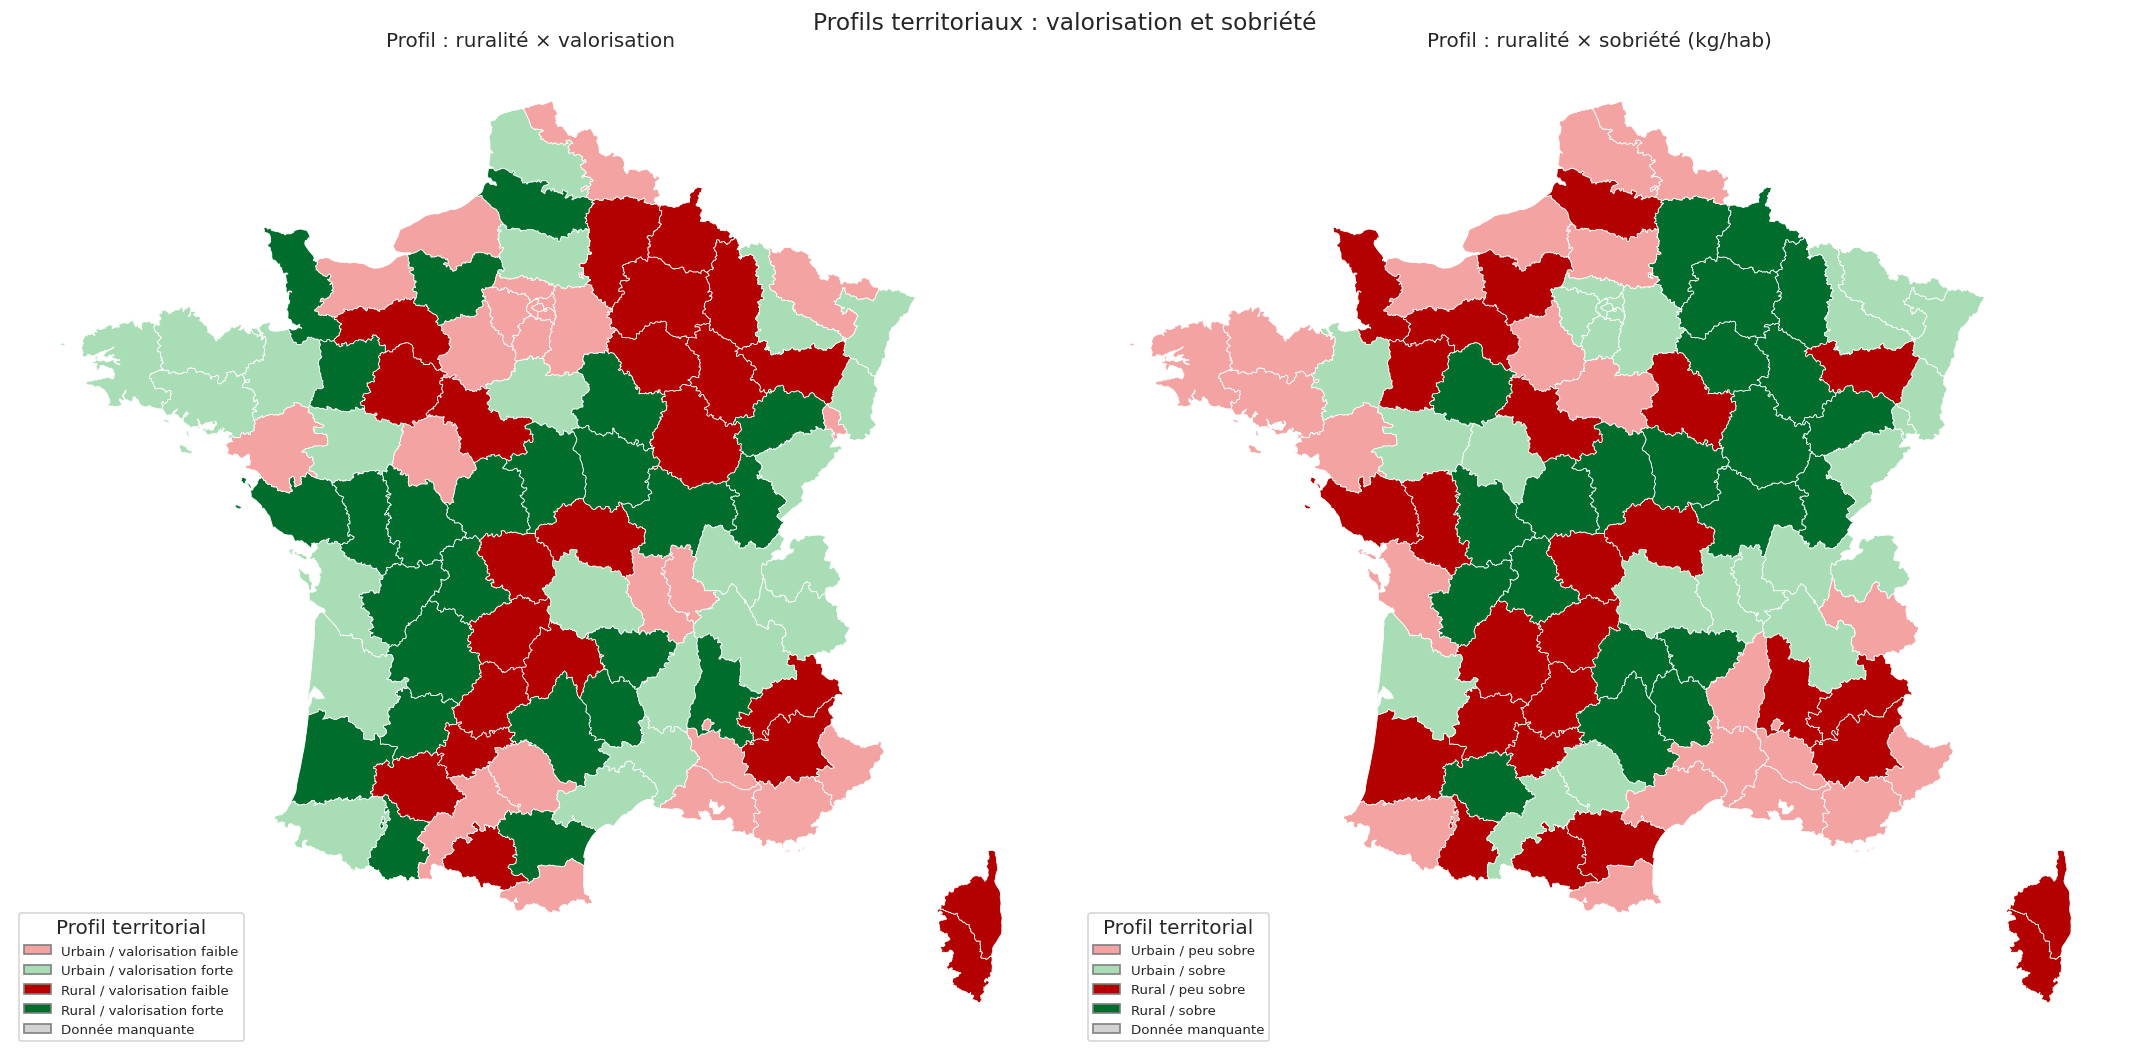

In [77]:
carte2 = charger_carte(df)
carte2["couleur"]         = carte2["profil"].map(couleurs)
carte2["couleur_sobriete"] = carte2["profil_sobriete"].map(couleurs_sobriete)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, col_couleur, titre, couleurs_dict in [
    (axes[0], "couleur",         "Profil : ruralité × valorisation",  couleurs),
    (axes[1], "couleur_sobriete", "Profil : ruralité × sobriété (kg/hab)", couleurs_sobriete),
]:
    carte2.plot(
        color=carte2[col_couleur].astype(object).fillna("lightgrey"),
        linewidth=0.5, edgecolor="white", ax=ax
    )
    legend_patches = [
        mpatches.Patch(facecolor=v, edgecolor="grey", label=k)
        for k, v in couleurs_dict.items()
    ] + [mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="Donnée manquante")]
    ax.legend(handles=legend_patches, title="Profil territorial",
              loc="lower left", frameon=True, fontsize=8)
    ax.set_title(titre, fontsize=12)
    ax.axis("off")

plt.suptitle("Profils territoriaux : valorisation et sobriété", fontsize=14)
plt.tight_layout()
plt.show()


**Lecture :**
- **Carte gauche (valorisation)** : les profils *rural / valorisation forte* (vert foncé) 
se concentrent dans le Massif Central, la Bretagne intérieure et le Grand Ouest — zones 
à forte tradition agricole et rurale. Les profils *rural / valorisation faible* (rouge foncé) 
sont des cas d'exception où la ruralité seule ne garantit pas une bonne performance.

- **Carte droite (sobriété)** : les profils *urbain / sobre* (vert clair) correspondent aux 
grandes métropoles denses (Paris, Lyon, Lille) où la structure des ménages en logements 
collectifs limite la production de déchets. Les profils *rural / peu sobre* (rouge foncé) 
sont souvent des départements touristiques (Landes, Finistère, Var) dont le kg/habitant 
est gonflé par la population estivale.

- **Comparaison des deux cartes** : les géographies sont distinctes, ce qui confirme que 
valorisation et sobriété mesurent deux dimensions indépendantes du comportement territorial 
face aux déchets.

## 4. Modélisation

### 4.1 Corrélations bivariées

In [78]:
def afficher_correlations(df, var1, var2, label1, label2):
    """Calcule et affiche les corrélations de Pearson et Spearman."""
    tmp = df[[var1, var2]].dropna()
    r_p, p_p = pearsonr(tmp[var1], tmp[var2])
    r_s, p_s = spearmanr(tmp[var1], tmp[var2])
    print(f"  {label1} × {label2}")
    print(f"  Pearson  r = {r_p:.3f}  (p = {p_p:.10f})")
    print(f"  Spearman ρ = {r_s:.3f}  (p = {p_s:.10f})")
    sig = "✅ significatif" if p_p < 0.05 else "❌ non significatif"
    print(f"  → {sig} au seuil 5 %\n")


afficher_correlations(df, "part_communes_rurales_pct", "taux_valorisation_pct",
                      "Ruralité", "Valorisation")
afficher_correlations(df, "niveau_vie_median", "taux_valorisation_pct",
                      "Niveau de vie", "Valorisation")
afficher_correlations(df, "part_communes_rurales_pct", "niveau_vie_median",
                      "Ruralité", "Niveau de vie")
afficher_correlations(df, "kg_dma_par_habitant", "taux_valorisation_pct",
                      "kg DMA/hab", "Valorisation")
afficher_correlations(df, "kg_dma_par_habitant", "part_communes_rurales_pct",
                      "kg DMA/hab", "Ruralité")
afficher_correlations(df, "kg_dma_par_habitant", "niveau_vie_median",
                      "kg DMA/hab", "Niveau de vie")

  Ruralité × Valorisation
  Pearson  r = 0.425  (p = 0.0000161464)
  Spearman ρ = 0.139  (p = 0.1772026465)
  → ✅ significatif au seuil 5 %

  Niveau de vie × Valorisation
  Pearson  r = -0.162  (p = 0.1151794970)
  Spearman ρ = -0.028  (p = 0.7847314422)
  → ❌ non significatif au seuil 5 %

  Ruralité × Niveau de vie
  Pearson  r = -0.543  (p = 0.0000000106)
  Spearman ρ = -0.543  (p = 0.0000000110)
  → ✅ significatif au seuil 5 %

  kg DMA/hab × Valorisation
  Pearson  r = 0.300  (p = 0.0030028633)
  Spearman ρ = 0.187  (p = 0.0686847745)
  → ✅ significatif au seuil 5 %

  kg DMA/hab × Ruralité
  Pearson  r = 0.414  (p = 0.0000273224)
  Spearman ρ = 0.172  (p = 0.0933370056)
  → ✅ significatif au seuil 5 %

  kg DMA/hab × Niveau de vie
  Pearson  r = -0.332  (p = 0.0009499334)
  Spearman ρ = -0.302  (p = 0.0027413203)
  → ✅ significatif au seuil 5 %



**Interprétation :**

**Ruralité × Valorisation** : corrélation positive significative selon Pearson (r = 0.425, 
p < 0.001) mais pas selon Spearman (ρ = 0.139, p = 0.177). La distribution très asymétrique 
de la ruralité crée des cas extrêmes qui gonflent le r de Pearson — à interpréter avec nuance.

**Niveau de vie × Valorisation** : aucune corrélation significative (Pearson et Spearman 
concordants). L'hypothèse socio-économique n'est pas validée à l'échelle départementale.

**Ruralité × Niveau de vie** : corrélation négative forte et significative (r = -0.543, 
p < 0.001) — les départements ruraux sont en moyenne moins riches. Risque de colinéarité 
partielle à surveiller dans la régression.

**kg DMA/hab × Valorisation** : corrélation positive significative selon Pearson (r = 0.300, 
p = 0.003) mais limite selon Spearman (ρ = 0.187, p = 0.069). Les départements qui produisent 
plus de déchets tendent à mieux les valoriser — cohérent avec l'hypothèse rurale 
(déchets organiques + compostage).

**kg DMA/hab × Ruralité** : corrélation positive significative (r = 0.414, p < 0.001) — 
les départements ruraux produisent plus de déchets par habitant, vraisemblablement 
des déchets organiques et verts liés aux jardins.

**kg DMA/hab × Niveau de vie** : corrélation négative significative (r = -0.332, p < 0.001, 
Spearman concordant). Les départements plus riches produisent moins de déchets par habitant 
— ce qui contraste avec l'absence de relation entre niveau de vie et taux de valorisation : 
être riche réduit la production mais n'améliore pas le tri.

⚠️ **Point d'attention Pour ruralité x Valorisation** : la corrélation de Pearson (r = 0.425, p < 0.001) 
et celle de Spearman (ρ = 0.139, p = 0.177) donnent des conclusions 
opposées. Cela s'explique par la forme de la relation : Pearson capte 
l'association linéaire, Spearman l'association monotone sur les rangs.
On retrouve un peu la même chose avec DMA et ruralité, pour les mêmes raisons.

La distribution très asymétrique de la ruralité (beaucoup de départements 
à > 90 %, quelques-uns à 0 %) crée des cas extrêmes qui "gonflent" le r 
de Pearson. Le résultat de Spearman invite à la prudence : la relation 
n'est pas robuste sur l'ensemble de la distribution. C'est une raison 
supplémentaire pour interpréter le modèle de régression avec nuance.

In [79]:
tmp = df[["taux_valorisation_pct", "part_communes_rurales_pct",
          "niveau_vie_median", "interaction_rural_revenu"]].dropna()

y = tmp["taux_valorisation_pct"]

# Modèle 1 : ruralité seule
X1 = sm.add_constant(tmp[["part_communes_rurales_pct"]])
mod1 = sm.OLS(y, X1).fit()

# Modèle 2 : ruralité + niveau de vie
X2 = sm.add_constant(tmp[["part_communes_rurales_pct", "niveau_vie_median"]])
mod2 = sm.OLS(y, X2).fit()

# Modèle 3 : ruralité + niveau de vie + interaction (variables centrées)
X3 = sm.add_constant(tmp[["part_communes_rurales_pct", "niveau_vie_median", "interaction_rural_revenu"]])
mod3 = sm.OLS(y, X3).fit()

# Tableau de synthèse
synthese = pd.DataFrame({
    "Modèle 1 (ruralité)": [
        f"{mod1.params['part_communes_rurales_pct']:.3f} ({'*' if mod1.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        "—", "—", f"{mod1.rsquared:.3f}", f"{mod1.rsquared_adj:.3f}", f"{mod1.fvalue:.2f} (p={mod1.f_pvalue:.4f})"
    ],
    "Modèle 2 (+revenu)": [
        f"{mod2.params['part_communes_rurales_pct']:.3f} ({'*' if mod2.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        f"{mod2.params['niveau_vie_median']:.4f} ({'*' if mod2.pvalues['niveau_vie_median']<0.05 else 'ns'})",
        "—", f"{mod2.rsquared:.3f}", f"{mod2.rsquared_adj:.3f}", f"{mod2.fvalue:.2f} (p={mod2.f_pvalue:.4f})"
    ],
    "Modèle 3 (+interaction)": [
        f"{mod3.params['part_communes_rurales_pct']:.3f} ({'*' if mod3.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        f"{mod3.params['niveau_vie_median']:.4f} ({'*' if mod3.pvalues['niveau_vie_median']<0.05 else 'ns'})",
        f"{mod3.params['interaction_rural_revenu']:.5f} ({'*' if mod3.pvalues['interaction_rural_revenu']<0.05 else 'ns'})",
        f"{mod3.rsquared:.3f}", f"{mod3.rsquared_adj:.3f}", f"{mod3.fvalue:.2f} (p={mod3.f_pvalue:.4f})"
    ]
}, index=["Part communes rurales", "Niveau de vie médian", "Interaction (centré)",
          "R²", "R² ajusté", "F-stat"])

display(synthese)
print("\n* = significatif à 5 % | ns = non significatif")

,Modèle 1 (ruralité),Modèle 2 (+revenu),Modèle 3 (+interaction)
Part communes rurales,0.191 (*),0.214 (*),0.205 (*)
Niveau de vie médian,—,0.0006 (ns),0.0011 (ns)
Interaction (centré),—,—,0.00002 (ns)
R²,0.180,0.187,0.200
R² ajusté,0.172,0.170,0.174
F-stat,20.68 (p=0.0000),10.70 (p=0.0001),7.65 (p=0.0001)



* = significatif à 5 % | ns = non significatif


In [80]:
# Résumé complet du modèle 3
print(mod3.summary())

                              OLS Regression Results                             
Dep. Variable:     taux_valorisation_pct   R-squared:                       0.200
Model:                               OLS   Adj. R-squared:                  0.174
Method:                    Least Squares   F-statistic:                     7.650
Date:                   Fri, 10 Apr 2026   Prob (F-statistic):           0.000128
Time:                           09:00:50   Log-Likelihood:                -343.91
No. Observations:                     96   AIC:                             695.8
Df Residuals:                         92   BIC:                             706.1
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

**Interprétation des modèles :**

**Modèle 1** : La ruralité seule explique **18 %** de la variance du taux 
de valorisation (R² = 0.180, R² ajusté = 0.172). Le coefficient est positif 
et très significatif (β = 0.191, p < 0.001) : une hausse d'un point de la 
part de communes rurales est associée à +0.19 pt de taux de valorisation.

**Modèle 2** : L'ajout du niveau de vie améliore marginalement le R² 
(passage de 18 % à 18.7 %). Le R² **ajusté** recule légèrement (0.172 → 
0.170), ce qui signifie que le niveau de vie n'apporte pas d'information 
utile au-delà du bruit. La ruralité reste significative (β = 0.214, p < 
0.001) ; le niveau de vie reste non significatif (p = 0.156).

**Modèle 3** : L'interaction n'est pas significative (p = 0.233). L'effet 
de la ruralité sur la valorisation ne varie donc pas selon la richesse du 
département. Le R² ajusté remonte légèrement à 0.174 mais reste modéré.
Le modèle 1 reste donc le plus parcimonieux et suffisant pour conclure.

### 4.3 Modèle complémentaire : déterminants de la sobriété (kg/habitant)

Le taux de valorisation mesure ce que les collectivités font des déchets **une fois produits**. Pour compléter l'analyse, on estime un second modèle OLS dont la variable dépendante est `kg_dma_par_habitant` — ce que les ménages **produisent** avant traitement.

On teste les mêmes variables explicatives (ruralité, niveau de vie) pour voir si elles jouent différemment sur la sobriété amont vs l'efficacité aval.


In [81]:
tmp_kg = df[["kg_dma_par_habitant", "part_communes_rurales_pct",
             "niveau_vie_median", "interaction_rural_revenu"]].dropna()

y_kg = tmp_kg["kg_dma_par_habitant"]

# Modèle A : ruralité seule → sobriété
XA = sm.add_constant(tmp_kg[["part_communes_rurales_pct"]])
modA = sm.OLS(y_kg, XA).fit()

# Modèle B : ruralité + niveau de vie → sobriété
XB = sm.add_constant(tmp_kg[["part_communes_rurales_pct", "niveau_vie_median"]])
modB = sm.OLS(y_kg, XB).fit()

# Tableau de synthèse comparatif
synthese_kg = pd.DataFrame({
    "Modèle A (ruralité → kg/hab)": [
        f"{modA.params['part_communes_rurales_pct']:.3f} ({'*' if modA.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        "—",
        f"{modA.rsquared:.3f}",
        f"{modA.rsquared_adj:.3f}",
    ],
    "Modèle B (ruralité+revenu → kg/hab)": [
        f"{modB.params['part_communes_rurales_pct']:.3f} ({'*' if modB.pvalues['part_communes_rurales_pct']<0.05 else 'ns'})",
        f"{modB.params['niveau_vie_median']:.4f} ({'*' if modB.pvalues['niveau_vie_median']<0.05 else 'ns'})",
        f"{modB.rsquared:.3f}",
        f"{modB.rsquared_adj:.3f}",
    ],
}, index=["Part communes rurales", "Niveau de vie médian", "R²", "R² ajusté"])

display(synthese_kg)
print("\n* = significatif à 5 % | ns = non significatif")
print(f"\nPour rappel — Modèle 1 (ruralité → taux valorisation) : R² = {mod1.rsquared:.3f}")
print(f"Modèle A (ruralité → kg/habitant)                     : R² = {modA.rsquared:.3f}")


,Modèle A (ruralité → kg/hab),Modèle B (ruralité+revenu → kg/hab)
Part communes rurales,1.996 (*),1.598 (*)
Niveau de vie médian,—,-0.0093 (ns)
R²,0.172,0.188
R² ajusté,0.163,0.170



* = significatif à 5 % | ns = non significatif

Pour rappel — Modèle 1 (ruralité → taux valorisation) : R² = 0.180
Modèle A (ruralité → kg/habitant)                     : R² = 0.172


**Interprétation comparative :**

En comparant les deux familles de modèles, on peut distinguer deux dimensions indépendantes du comportement territorial face aux déchets :

- **Taux de valorisation (aval)** : la ruralité est le déterminant principal. Les territoires ruraux valorisent mieux leurs déchets, probablement grâce à une plus grande capacité de compostage et de valorisation organique.

- **kg/habitant (amont)** : si le coefficient de la ruralité est positif ici aussi (plus rural = plus de déchets produits, notamment des déchets organiques et verts liés aux jardins), cela confirme que les deux indicateurs mesurent des phénomènes **complémentaires et non redondants** : produire beaucoup de déchets et bien les valoriser peuvent aller de pair en milieu rural.

> Cette distinction enrichit la réponse à notre problématique : le 'profil écologique' d'un territoire ne se réduit pas à un seul indicateur. Un département rural peut être à la fois grand producteur de déchets organiques (jardins, compost) et excellent valorisateur — ce qui n'est pas contradictoire.


### 4.4 Vérification des hypothèses du modèle OLS

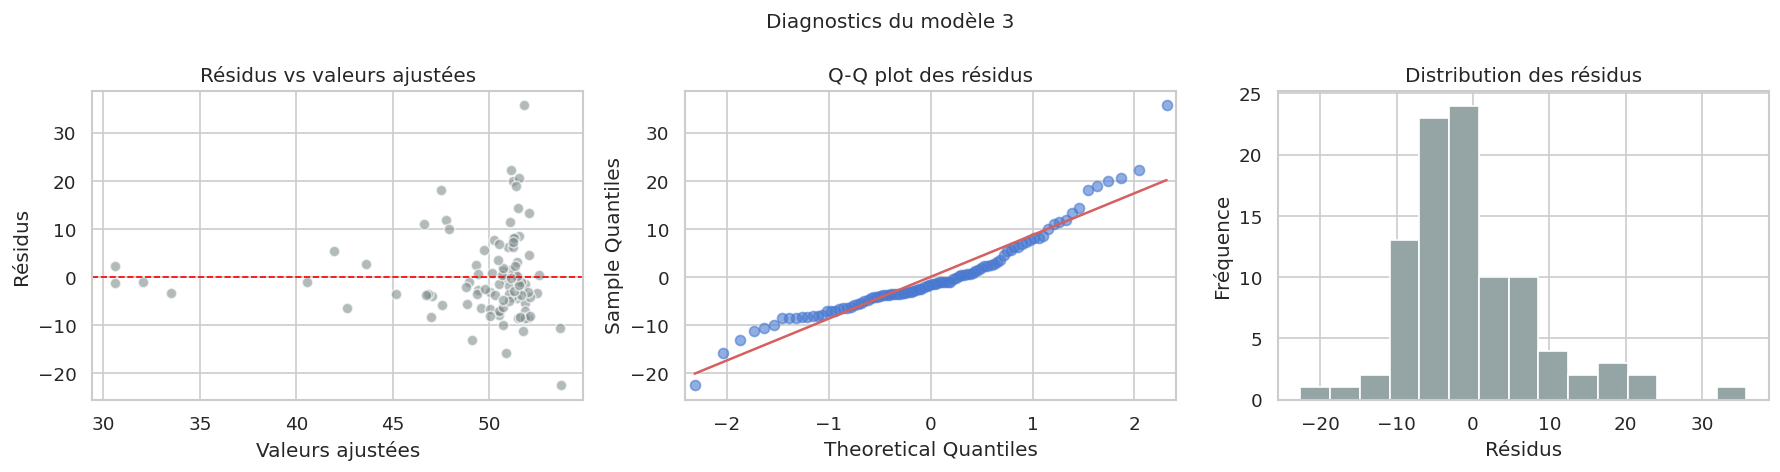

Test de Shapiro-Wilk : W = 0.9225, p = 0.0000
→ Les résidus s'écartent significativement de la normale (p < 0.05) — interpréter avec prudence


In [82]:
import numpy as np
from scipy.stats import shapiro

residus = mod3.resid
fitted  = mod3.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Résidus vs valeurs ajustées (homoscédasticité)
axes[0].scatter(fitted, residus, alpha=0.6, color="#7f8c8d", edgecolors="white", s=40)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valeurs ajustées")
axes[0].set_ylabel("Résidus")
axes[0].set_title("Résidus vs valeurs ajustées")

# 2. Q-Q plot (normalité)
sm.qqplot(residus, line="s", ax=axes[1], alpha=0.6)
axes[1].set_title("Q-Q plot des résidus")

# 3. Distribution des résidus
axes[2].hist(residus, bins=15, color="#95a5a6", edgecolor="white")
axes[2].set_xlabel("Résidus")
axes[2].set_ylabel("Fréquence")
axes[2].set_title("Distribution des résidus")

plt.suptitle("Diagnostics du modèle 3", fontsize=12)
plt.tight_layout()
plt.show()

# Test de Shapiro-Wilk
stat, p_sw = shapiro(residus)
print(f"Test de Shapiro-Wilk : W = {stat:.4f}, p = {p_sw:.4f}")
if p_sw > 0.05:
    print("→ On ne rejette pas l'hypothèse de normalité des résidus (p > 0.05)")
else:
    print("→ Les résidus s'écartent significativement de la normale (p < 0.05) — interpréter avec prudence")

**Lecture des diagnostics :**
- *Résidus vs valeurs ajustées* : le nuage est globalement centré sur 0 
  mais quelques points extrêmes en haut à gauche (forts résidus positifs 
  pour les hauts taux de valorisation) signalent une légère 
  hétéroscédasticité.
- *Q-Q plot* : les queues s'écartent de la diagonale, surtout à droite — 
  quelques départements outliers (Vendée, Saône-et-Loire) tirent la 
  distribution vers le haut.
- *Shapiro-Wilk* : W = 0.9225, p < 0.001 → on rejette la normalité. Les 
  p-values et intervalles de confiance de la régression sont donc à 
  interpréter avec prudence. Une solution serait de tester une 
  transformation log du taux de valorisation ou d'utiliser des erreurs 
  standard robustes (HC3).

## 5. Conclusion générale

Cette étude avait pour objectif d'identifier les facteurs territoriaux et socio-économiques associés à la gestion des déchets ménagers à l'échelle départementale en France, en distinguant deux dimensions complémentaires : l'efficacité du traitement en aval (`taux_valorisation_pct`) et la sobriété dans la production en amont (`kg_dma_par_habitant`).

**Principaux résultats :**

1. **La ruralité est positivement et significativement associée au taux de valorisation** (β = 0.191, p < 0.001, R² = 0.18). Cette relation se confirme à travers l'analyse descriptive, les corrélations, les cartes et la régression. Elle s'explique par une plus grande pratique du compostage et de la valorisation organique en milieu rural.

2. **Le niveau de vie médian n'est pas un déterminant significatif** ni du taux de valorisation ni de la production de déchets par habitant. L'hypothèse socio-économique n'est pas validée à l'échelle départementale : ce ne sont pas les territoires les plus riches qui valorisent le mieux.

3. **Le terme d'interaction ruralité × revenu n'est pas significatif** (p = 0.233) : l'effet de la ruralité sur la valorisation est indépendant du niveau de richesse du département.

4. **Les deux indicateurs mesurent des phénomènes distincts.** La ruralité est associée à la fois à un fort taux de valorisation et à une production plus élevée de déchets par habitant (déchets verts, organiques liés aux jardins). Cela confirme qu'un territoire peut être à la fois grand producteur de déchets organiques et excellent valorisateur — ce qui n'est pas contradictoire et enrichit la lecture du 'profil écologique' d'un département.

**Limites :**
- L'indicateur de ruralité n'est pas pondéré par la population, ce qui sur-représente les communes faiblement peuplées.
- Le `kg_dma_par_habitant` est biaisé par le tourisme : les départements très touristiques (Landes, Var) apparaissent comme grands producteurs alors que leur population estivale réelle est bien supérieure à la population légale utilisée pour normaliser.
- Le modèle explique une part limitée de la variance (R² ~ 18 %) : d'autres facteurs (densité de déchèteries, politiques locales, part de maisons individuelles avec jardin) mériteraient d'être intégrés.
- L'analyse est transversale (2021) : une approche longitudinale permettrait de contrôler des effets fixes départementaux et d'observer les tendances dans le temps.

**Pistes d'approfondissement :** intégration de la densité de déchèteries par département (disponible dans SINOE), de la part de logements individuels avec jardin (INSEE RP), on peut aussi envisager une étude dans le temps en recherchant des données plus anciennes.


In [83]:
import subprocess

result = subprocess.run(
    [
        "jupyter", "nbconvert",
        "--to", "html",
        "--no-input",
        "notebook_recyclage_DMR.ipynb"
    ],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("✅ HTML généré : notebook_recyclage_DMR.html")
else:
    print("❌ Erreur :")
    print(result.stderr)

✅ HTML généré : notebook_recyclage_DMR.html


✅ HTML généré : notebook_recyclage_DMR.html


✅ HTML généré : notebook_recyclage_DMR.html
